# Movie Genre Classification with NLP

## Version
**V2 — Feature Engineering & Model Comparison**

### Objective
Improve the baseline model developed in V1 by applying feature engineering techniques and comparing multiple machine learning algorithms.

### Baseline (V1)
- TF-IDF (max_features=5000)
- Unigram
- Logistic Regression
- Accuracy: 39.34%

### Goals
- Improve overall accuracy
- Improve Macro F1-score
- Improve prediction for minority genres
- Compare multiple machine learning models

In [3]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

## Project Configuration

In [4]:
PROJECT_ROOT = Path("../..")

DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODEL_DIR = PROJECT_ROOT / "v2-model-comparison" / "models"

OUTPUT_DIR = PROJECT_ROOT / "v2-model-comparison" / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Load Processed Dataset

In [5]:
df = pd.read_csv(
    PROCESSED_DATA_DIR / "movies_clean.csv"
)

df.head()

,title,overview,genre
0,Avatar,in the century a paraplegic marine is dispatch...,Action
1,Pirates of the Caribbean: At World's End,captain barbossa long believed to be dead has ...,Adventure
2,Spectre,a cryptic message from bonds past sends him on...,Action
3,The Dark Knight Rises,following the death of district attorney harve...,Action
4,John Carter,john carter is a warweary former military capt...,Action


## Dataset Summary

In [6]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Jumlah data       : {len(df)}")
print(f"Jumlah genre      : {df['genre'].nunique()}")

print("\nDistribusi Genre")
print(df["genre"].value_counts())

print("\nRata-rata panjang overview")
print(
    round(
        df["overview"].str.split().str.len().mean(),
        2
    ),
    "kata"
)

DATASET SUMMARY
Jumlah data       : 4689
Jumlah genre      : 15

Distribusi Genre
genre
Drama              1206
Comedy             1042
Action              753
Adventure           339
Horror              300
Crime               195
Thriller            194
Animation           123
Fantasy             117
Romance             106
Science Fiction      96
Documentary          87
Family               56
Mystery              41
Music                34
Name: count, dtype: int64

Rata-rata panjang overview
51.68 kata


In [7]:
X = df["overview"]
y = df["genre"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                lowercase=False,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Accuracy : 0.3934
                 precision    recall  f1-score   support

         Action       0.39      0.49      0.43       151
      Adventure       0.33      0.04      0.08        68
      Animation       0.00      0.00      0.00        25
         Comedy       0.40      0.56      0.46       209
          Crime       0.00      0.00      0.00        39
    Documentary       0.00      0.00      0.00        17
          Drama       0.39      0.69      0.50       241
         Family       0.00      0.00      0.00        11
        Fantasy       0.00      0.00      0.00        23
         Horror       0.53      0.15      0.23        60
          Music       0.00      0.00      0.00         7
        Mystery       0.00      0.00      0.00         8
        Romance       0.00      0.00      0.00        21
Science Fiction       0.00      0.00      0.00        19
       Thriller       0.00      0.00      0.00        39

       accuracy                           0.39       938
      macro

# Experiment 1 — Stopword Removal

## Objective

Evaluate whether removing English stopwords improves the baseline model.

### Change from Baseline

- TF-IDF
- max_features = 5000
- unigram
- **stop_words = "english"**
- Logistic Regression

In [10]:
pipeline_stopwords = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                lowercase=False,
                stop_words="english",
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)

pipeline_stopwords.fit(X_train, y_train)

y_pred_stop = pipeline_stopwords.predict(X_test)

In [11]:
accuracy_stop = accuracy_score(y_test, y_pred_stop)

print("=" * 50)
print("Experiment 1")
print("Stopword Removal")
print("=" * 50)

print(f"Accuracy : {accuracy_stop:.4f}")

print()

print(
    classification_report(
        y_test,
        y_pred_stop,
        zero_division=0
    )
)

Experiment 1
Stopword Removal
Accuracy : 0.3966

                 precision    recall  f1-score   support

         Action       0.42      0.51      0.46       151
      Adventure       0.45      0.07      0.13        68
      Animation       0.00      0.00      0.00        25
         Comedy       0.39      0.57      0.46       209
          Crime       0.00      0.00      0.00        39
    Documentary       0.00      0.00      0.00        17
          Drama       0.39      0.67      0.49       241
         Family       0.00      0.00      0.00        11
        Fantasy       0.00      0.00      0.00        23
         Horror       0.44      0.13      0.21        60
          Music       0.00      0.00      0.00         7
        Mystery       0.00      0.00      0.00         8
        Romance       0.00      0.00      0.00        21
Science Fiction       0.00      0.00      0.00        19
       Thriller       0.00      0.00      0.00        39

       accuracy                      

In [12]:
results = pd.DataFrame(
    {
        "Experiment": ["Baseline", "Stopword Removal"],
        "Accuracy": [
            accuracy,
            accuracy_stop,
        ],
    }
)

results

,Experiment,Accuracy
0,Baseline,0.393390
1,Stopword Removal,0.396588


## Result

Removing English stopwords slightly improved the baseline accuracy from **39.34%** to **39.66%**.

The improvement indicates that common English words contribute a small amount of noise in the TF-IDF representation. However, the increase is marginal, and the model still struggles to classify minority genres.

**Conclusion:** Stopword removal provides a small benefit but is not sufficient to address the overall classification problem.

In [13]:
results = []

results.append({
    "Experiment": "Baseline",
    "Accuracy": accuracy
})

results.append({
    "Experiment": "Stopword Removal",
    "Accuracy": accuracy_stop
})

results_df = pd.DataFrame(results)

results_df

,Experiment,Accuracy
0,Baseline,0.393390
1,Stopword Removal,0.396588


# Experiment 2 — Unigram + Bigram

## Objective

Evaluate whether adding bigram features improves movie genre classification.

### Change from Previous Experiment

- TF-IDF
- max_features = 5000
- stop_words = "english"
- **ngram_range = (1, 2)**
- Logistic Regression

In [14]:
pipeline_ngram = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                lowercase=False,
                stop_words="english",
                ngram_range=(1, 2),
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)

pipeline_ngram.fit(X_train, y_train)

y_pred_ngram = pipeline_ngram.predict(X_test)

In [15]:
accuracy_ngram = accuracy_score(y_test, y_pred_ngram)

print("=" * 50)
print("Experiment 2")
print("Unigram + Bigram")
print("=" * 50)

print(f"Accuracy : {accuracy_ngram:.4f}")

print()

print(
    classification_report(
        y_test,
        y_pred_ngram,
        zero_division=0
    )
)

Experiment 2
Unigram + Bigram
Accuracy : 0.3998

                 precision    recall  f1-score   support

         Action       0.41      0.50      0.45       151
      Adventure       0.42      0.07      0.12        68
      Animation       0.00      0.00      0.00        25
         Comedy       0.39      0.58      0.47       209
          Crime       0.00      0.00      0.00        39
    Documentary       0.00      0.00      0.00        17
          Drama       0.39      0.68      0.50       241
         Family       0.00      0.00      0.00        11
        Fantasy       0.00      0.00      0.00        23
         Horror       0.53      0.13      0.21        60
          Music       0.00      0.00      0.00         7
        Mystery       0.00      0.00      0.00         8
        Romance       0.00      0.00      0.00        21
Science Fiction       0.00      0.00      0.00        19
       Thriller       0.00      0.00      0.00        39

       accuracy                      

In [16]:
results.append(
    {
        "Experiment": "Unigram + Bigram",
        "Accuracy": accuracy_ngram,
    }
)

results_df = pd.DataFrame(results)

results_df

,Experiment,Accuracy
0,Baseline,0.393390
1,Stopword Removal,0.396588
2,Unigram + Bigram,0.399787


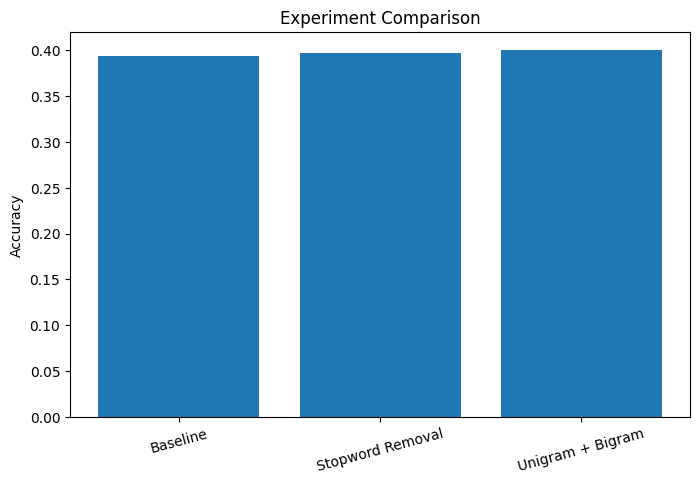

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Experiment"],
    results_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Experiment Comparison")

plt.xticks(rotation=15)

plt.show()

## Result

Adding bigram features improved the accuracy from **39.66%** to **39.98%**.

The model benefits from learning meaningful two-word phrases such as *space ship*, *serial killer*, and *high school*. However, the improvement is still relatively small, and the classifier continues to struggle with minority genres.

**Conclusion:** Unigram + Bigram performs better than using unigram alone and will be used as the new baseline for the next experiments.

# Experiment 3 — Class Weight Balancing

## Objective

Evaluate whether balancing class weights improves genre classification, especially for minority classes.

### Change from Previous Experiment

- TF-IDF
- max_features = 5000
- stop_words = "english"
- ngram_range = (1, 2)
- **class_weight = "balanced"**

In [18]:
pipeline_balanced = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                lowercase=False,
                stop_words="english",
                ngram_range=(1, 2),
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000,
                class_weight="balanced",
            ),
        ),
    ]
)

pipeline_balanced.fit(X_train, y_train)

y_pred_balanced = pipeline_balanced.predict(X_test)

In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)

accuracy_balanced = accuracy_score(
    y_test,
    y_pred_balanced,
)

_, _, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_balanced,
    average="macro",
    zero_division=0,
)

_, _, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_balanced,
    average="weighted",
    zero_division=0,
)

print("=" * 50)
print("Experiment 3")
print("Balanced Class Weight")
print("=" * 50)

print(f"Accuracy     : {accuracy_balanced:.4f}")
print(f"Macro F1     : {macro_f1:.4f}")
print(f"Weighted F1  : {weighted_f1:.4f}")

print()

print(
    classification_report(
        y_test,
        y_pred_balanced,
        zero_division=0,
    )
)

Experiment 3
Balanced Class Weight
Accuracy     : 0.3486
Macro F1     : 0.2119
Weighted F1  : 0.3672

                 precision    recall  f1-score   support

         Action       0.47      0.40      0.43       151
      Adventure       0.24      0.25      0.25        68
      Animation       0.30      0.28      0.29        25
         Comedy       0.55      0.44      0.49       209
          Crime       0.15      0.26      0.19        39
    Documentary       0.29      0.41      0.34        17
          Drama       0.54      0.38      0.44       241
         Family       0.00      0.00      0.00        11
        Fantasy       0.10      0.13      0.12        23
         Horror       0.33      0.52      0.41        60
          Music       0.00      0.00      0.00         7
        Mystery       0.00      0.00      0.00         8
        Romance       0.02      0.05      0.03        21
Science Fiction       0.11      0.21      0.15        19
       Thriller       0.04      0.05      

In [20]:
from sklearn.metrics import f1_score

results = [
    {
        "Experiment": "Baseline",
        "Accuracy": accuracy,
        "Macro F1": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
    },
    {
        "Experiment": "Stopword Removal",
        "Accuracy": accuracy_stop,
        "Macro F1": f1_score(
            y_test,
            y_pred_stop,
            average="macro",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            y_test,
            y_pred_stop,
            average="weighted",
            zero_division=0,
        ),
    },
    {
        "Experiment": "Unigram + Bigram",
        "Accuracy": accuracy_ngram,
        "Macro F1": f1_score(
            y_test,
            y_pred_ngram,
            average="macro",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            y_test,
            y_pred_ngram,
            average="weighted",
            zero_division=0,
        ),
    },
    {
        "Experiment": "Balanced",
        "Accuracy": accuracy_balanced,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
    },
]

results_df = pd.DataFrame(results)

results_df

,Experiment,Accuracy,Macro F1,Weighted F1
0,Baseline,0.393390,0.113788,0.321602
1,Stopword Removal,0.396588,0.116558,0.326263
2,Unigram + Bigram,0.399787,0.117282,0.328451
3,Balanced,0.348614,0.211875,0.367211


## Result

Applying balanced class weights significantly improved the model's ability to classify minority genres.

Although the overall accuracy decreased from **39.98%** to **34.86%**, the Macro F1-score increased from **0.1173** to **0.2119**, indicating a much more balanced classifier.

Several minority genres such as Documentary, Animation, Crime, and Science Fiction, which were previously never predicted, are now correctly identified.

**Conclusion:** Class balancing greatly improves fairness across classes but sacrifices overall accuracy.

# Experiment 4 — Linear Support Vector Machine (LinearSVC)

## Objective

Evaluate whether LinearSVC performs better than Logistic Regression on TF-IDF features.

### Change from Experiment 2

- TF-IDF
- stop_words = "english"
- ngram_range = (1,2)
- **LinearSVC**

In [22]:
from sklearn.svm import LinearSVC

pipeline_svm = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                lowercase=False,
                stop_words="english",
                ngram_range=(1, 2),
            ),
        ),
        (
            "classifier",
            LinearSVC(
                random_state=42,
            ),
        ),
    ]
)

pipeline_svm.fit(X_train, y_train)

y_pred_svm = pipeline_svm.predict(X_test)

In [23]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
)

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm,
)

macro_f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="macro",
    zero_division=0,
)

weighted_f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0,
)

print("=" * 50)
print("Experiment 4")
print("LinearSVC")
print("=" * 50)

print(f"Accuracy     : {accuracy_svm:.4f}")
print(f"Macro F1     : {macro_f1_svm:.4f}")
print(f"Weighted F1  : {weighted_f1_svm:.4f}")

print()

print(
    classification_report(
        y_test,
        y_pred_svm,
        zero_division=0,
    )
)

Experiment 4
LinearSVC
Accuracy     : 0.3902
Macro F1     : 0.1671
Weighted F1  : 0.3552

                 precision    recall  f1-score   support

         Action       0.41      0.47      0.44       151
      Adventure       0.30      0.22      0.25        68
      Animation       0.00      0.00      0.00        25
         Comedy       0.43      0.56      0.48       209
          Crime       0.20      0.08      0.11        39
    Documentary       0.29      0.12      0.17        17
          Drama       0.42      0.56      0.48       241
         Family       0.00      0.00      0.00        11
        Fantasy       0.20      0.04      0.07        23
         Horror       0.35      0.32      0.33        60
          Music       0.00      0.00      0.00         7
        Mystery       0.00      0.00      0.00         8
        Romance       0.00      0.00      0.00        21
Science Fiction       0.18      0.11      0.13        19
       Thriller       0.05      0.03      0.03        

In [24]:
results.append(
    {
        "Experiment": "LinearSVC",
        "Accuracy": accuracy_svm,
        "Macro F1": macro_f1_svm,
        "Weighted F1": weighted_f1_svm,
    }
)

results_df = pd.DataFrame(results).round(4)

results_df

,Experiment,Accuracy,Macro F1,Weighted F1
0,Baseline,0.3934,0.1138,0.3216
1,Stopword Removal,0.3966,0.1166,0.3263
2,Unigram + Bigram,0.3998,0.1173,0.3285
3,Balanced,0.3486,0.2119,0.3672
4,LinearSVC,0.3902,0.1671,0.3552


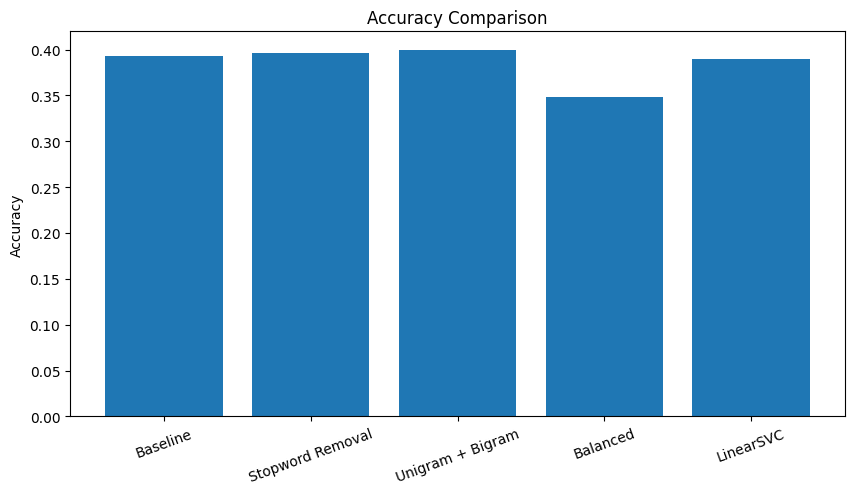

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Experiment"], results_df["Accuracy"])

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

## Result

Replacing Logistic Regression with **LinearSVC** resulted in a slightly lower accuracy (**39.02%** vs **39.98%**). However, the model achieved a noticeable improvement in both **Macro F1-score** and **Weighted F1-score**, indicating better performance across multiple classes.

LinearSVC was able to recognize more minority genres than the standard Logistic Regression model, although its performance was still lower than the balanced Logistic Regression in terms of class fairness.

**Conclusion:** LinearSVC provides a better balance between overall accuracy and class-wise performance, making it a strong candidate for text classification tasks.

# Experiment 5 — Multinomial Naive Bayes

## Objective

Evaluate the performance of Multinomial Naive Bayes for movie genre classification.

### Change from Experiment 2

- TF-IDF
- stop_words = "english"
- ngram_range = (1,2)
- **Multinomial Naive Bayes**

In [27]:
from sklearn.naive_bayes import MultinomialNB

pipeline_nb = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                lowercase=False,
                stop_words="english",
                ngram_range=(1, 2),
            ),
        ),
        (
            "classifier",
            MultinomialNB(),
        ),
    ]
)

pipeline_nb.fit(X_train, y_train)

y_pred_nb = pipeline_nb.predict(X_test)

In [28]:
accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb,
)

macro_f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="macro",
    zero_division=0,
)

weighted_f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0,
)

print("=" * 50)
print("Experiment 5")
print("Multinomial Naive Bayes")
print("=" * 50)

print(f"Accuracy     : {accuracy_nb:.4f}")
print(f"Macro F1     : {macro_f1_nb:.4f}")
print(f"Weighted F1  : {weighted_f1_nb:.4f}")

print()

print(
    classification_report(
        y_test,
        y_pred_nb,
        zero_division=0,
    )
)

Experiment 5
Multinomial Naive Bayes
Accuracy     : 0.3774
Macro F1     : 0.0905
Weighted F1  : 0.2931

                 precision    recall  f1-score   support

         Action       0.41      0.42      0.42       151
      Adventure       0.00      0.00      0.00        68
      Animation       0.00      0.00      0.00        25
         Comedy       0.40      0.56      0.47       209
          Crime       0.00      0.00      0.00        39
    Documentary       0.00      0.00      0.00        17
          Drama       0.35      0.71      0.47       241
         Family       0.00      0.00      0.00        11
        Fantasy       0.00      0.00      0.00        23
         Horror       0.00      0.00      0.00        60
          Music       0.00      0.00      0.00         7
        Mystery       0.00      0.00      0.00         8
        Romance       0.00      0.00      0.00        21
Science Fiction       0.00      0.00      0.00        19
       Thriller       0.00      0.00    

In [29]:
results.append(
    {
        "Experiment": "MultinomialNB",
        "Accuracy": accuracy_nb,
        "Macro F1": macro_f1_nb,
        "Weighted F1": weighted_f1_nb,
    }
)

results_df = pd.DataFrame(results).round(4)

results_df

,Experiment,Accuracy,Macro F1,Weighted F1
0,Baseline,0.3934,0.1138,0.3216
1,Stopword Removal,0.3966,0.1166,0.3263
2,Unigram + Bigram,0.3998,0.1173,0.3285
3,Balanced,0.3486,0.2119,0.3672
4,LinearSVC,0.3902,0.1671,0.3552
5,MultinomialNB,0.3774,0.0905,0.2931


## Result

Multinomial Naive Bayes achieved lower performance than both Logistic Regression and LinearSVC.

The model obtained an accuracy of **37.74%**, with the lowest Macro F1-score (**0.0905**) and Weighted F1-score (**0.2931**) among all evaluated models. Most minority genres were never predicted, indicating that Multinomial Naive Bayes was unable to capture the complex decision boundaries required for this dataset.

**Conclusion:** Multinomial Naive Bayes is not suitable for this movie genre classification task and will not be selected for further optimization.

### Experiment Summary

| Metric | Value |
|--------|------:|
| Accuracy | **37.74%** |
| Macro F1 | **0.0905** |
| Weighted F1 | **0.2931** |

**Key Findings**
- Lowest performance among all evaluated models.
- Failed to classify most minority genres.
- Inferior to Logistic Regression and LinearSVC.
- Not selected for further experiments.

# Experiment 6 — TF-IDF Feature Size

## Objective

Evaluate the impact of different TF-IDF vocabulary sizes on model performance.

### Fixed Configuration

- Stopword Removal
- Unigram + Bigram
- Logistic Regression

### Variable

- max_features

In [30]:
feature_results = []

feature_sizes = [
    5000,
    10000,
    15000,
    20000,
    None,
]

for size in feature_sizes:

    pipeline = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=size,
                    stop_words="english",
                    lowercase=False,
                    ngram_range=(1, 2),
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    random_state=42,
                    max_iter=1000,
                ),
            ),
        ]
    )

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    feature_results.append(
        {
            "max_features": size,
            "Accuracy": accuracy_score(y_test, pred),
            "Macro F1": f1_score(
                y_test,
                pred,
                average="macro",
                zero_division=0,
            ),
            "Weighted F1": f1_score(
                y_test,
                pred,
                average="weighted",
                zero_division=0,
            ),
        }
    )

In [31]:
feature_df = pd.DataFrame(feature_results)

feature_df

,max_features,Accuracy,Macro F1,Weighted F1
0,5000.0,0.399787,0.117282,0.328451
1,10000.0,0.399787,0.115471,0.326370
2,15000.0,0.393390,0.110698,0.318363
3,20000.0,0.396588,0.111382,0.320663
4,NaN,0.382729,0.095760,0.299942


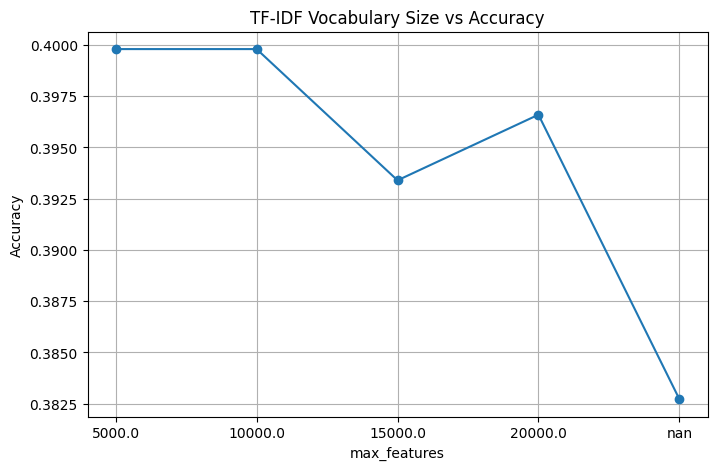

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    feature_df["max_features"].astype(str),
    feature_df["Accuracy"],
    marker="o",
)

plt.title("TF-IDF Vocabulary Size vs Accuracy")
plt.xlabel("max_features")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

## Result

Increasing the TF-IDF vocabulary size did not improve the model performance.

The best results were obtained using **5,000 features**, while larger vocabularies introduced additional noise and slightly reduced the overall performance.

Using the complete vocabulary (`max_features=None`) produced the lowest scores across all evaluation metrics.

**Conclusion:** A vocabulary size of **5,000** provides the best trade-off between model complexity and predictive performance for this dataset.

### Experiment Summary

| Best Parameter | Value |
|---------------|------:|
| max_features | **5000** |

**Key Findings**

- Increasing the vocabulary size did not improve performance.
- 5,000 features achieved the highest Accuracy, Macro F1, and Weighted F1 among the tested values.
- Larger vocabularies introduced additional noise.
- `max_features = 5000` will be retained for the remaining experiments.

# Experiment 7 — Logistic Regression Hyperparameter Tuning

## Objective

Evaluate the effect of different regularization strengths (`C`) on Logistic Regression performance.

### Fixed Configuration

- TF-IDF
- max_features = 5000
- stop_words = "english"
- ngram_range = (1,2)

### Variable

- C

In [33]:
c_values = [
    0.01,
    0.1,
    0.5,
    1,
    2,
    5,
    10,
]

c_results = []

for c in c_values:

    pipeline = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=5000,
                    stop_words="english",
                    lowercase=False,
                    ngram_range=(1, 2),
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    C=c,
                    random_state=42,
                    max_iter=1000,
                ),
            ),
        ]
    )

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    c_results.append(
        {
            "C": c,
            "Accuracy": accuracy_score(y_test, pred),
            "Macro F1": f1_score(
                y_test,
                pred,
                average="macro",
                zero_division=0,
            ),
            "Weighted F1": f1_score(
                y_test,
                pred,
                average="weighted",
                zero_division=0,
            ),
        }
    )

In [34]:
c_df = pd.DataFrame(c_results)

c_df

,C,Accuracy,Macro F1,Weighted F1
0,0.01,0.256930,0.027255,0.105038
1,0.10,0.311301,0.059898,0.209520
2,0.50,0.378465,0.092438,0.294849
3,1.00,0.399787,0.117282,0.328451
4,2.00,0.402985,0.133699,0.342851
5,5.00,0.399787,0.151989,0.349169
6,10.00,0.404051,0.168945,0.361039


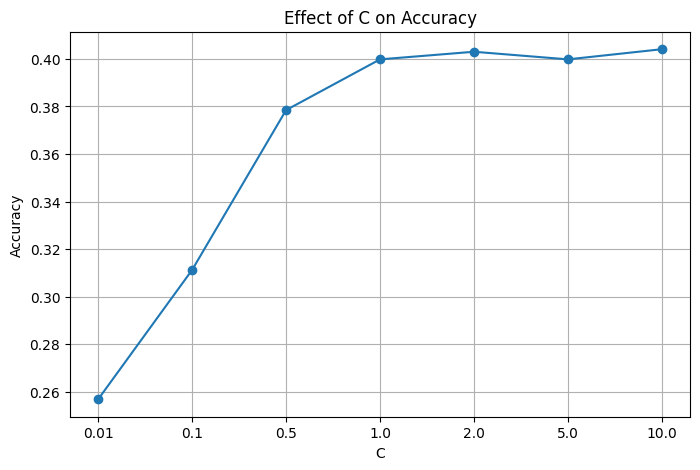

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    c_df["C"].astype(str),
    c_df["Accuracy"],
    marker="o",
)

plt.title("Effect of C on Accuracy")
plt.xlabel("C")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

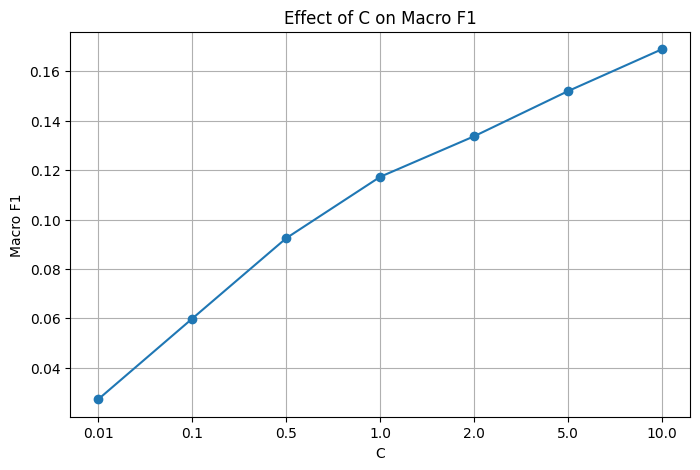

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    c_df["C"].astype(str),
    c_df["Macro F1"],
    marker="o",
)

plt.title("Effect of C on Macro F1")
plt.xlabel("C")
plt.ylabel("Macro F1")

plt.grid(True)

plt.show()

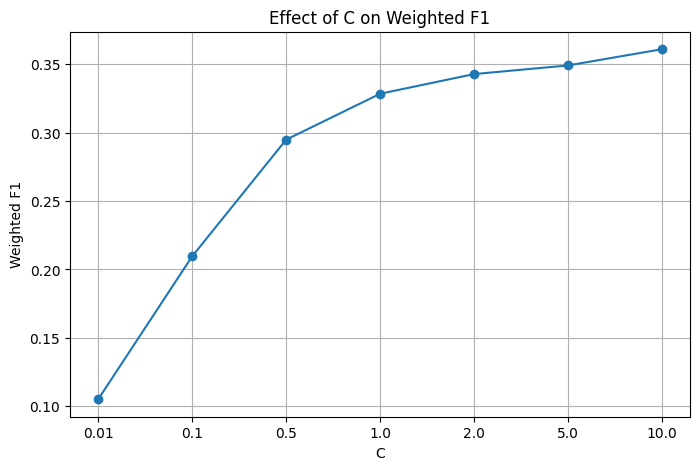

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    c_df["C"].astype(str),
    c_df["Weighted F1"],
    marker="o",
)

plt.title("Effect of C on Weighted F1")
plt.xlabel("C")
plt.ylabel("Weighted F1")

plt.grid(True)

plt.show()

## Result

Increasing the regularization parameter (`C`) consistently improved the model performance.

Higher values of `C` allowed the Logistic Regression model to learn more complex decision boundaries, resulting in better classification performance across all evaluation metrics.

Among the evaluated values, **C = 10** achieved the highest Accuracy, Macro F1-score, and Weighted F1-score.

**Conclusion:** The default regularization strength was too restrictive for this dataset. Therefore, **C = 10** will be selected as the optimal parameter.

### Experiment Summary

| Best Parameter | Value |
|---------------|------:|
| C | **10** |

**Key Findings**

- Performance improved as the regularization became weaker.
- The best Accuracy was obtained with **C = 10**.
- Macro F1 and Weighted F1 also reached their highest values at **C = 10**.
- `C = 10` will be used as the final Logistic Regression configuration.

# Experiment 8 — Balanced Logistic Regression with Optimized Regularization

## Objective

Combine the best regularization parameter (`C = 10`) with class balancing to improve both overall accuracy and minority class performance.

### Fixed Configuration

- TF-IDF
- max_features = 5000
- stop_words = "english"
- ngram_range = (1,2)

### Model

- Logistic Regression
- C = 10
- class_weight = "balanced"

In [38]:
pipeline_balanced_c10 = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                stop_words="english",
                lowercase=False,
                ngram_range=(1, 2),
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                C=10,
                class_weight="balanced",
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)

pipeline_balanced_c10.fit(X_train, y_train)

y_pred_balanced_c10 = pipeline_balanced_c10.predict(X_test)

In [39]:
accuracy_balanced_c10 = accuracy_score(
    y_test,
    y_pred_balanced_c10,
)

macro_f1_balanced_c10 = f1_score(
    y_test,
    y_pred_balanced_c10,
    average="macro",
    zero_division=0,
)

weighted_f1_balanced_c10 = f1_score(
    y_test,
    y_pred_balanced_c10,
    average="weighted",
    zero_division=0,
)

print("=" * 50)
print("Experiment 8")
print("Balanced Logistic Regression (C = 10)")
print("=" * 50)

print(f"Accuracy     : {accuracy_balanced_c10:.4f}")
print(f"Macro F1     : {macro_f1_balanced_c10:.4f}")
print(f"Weighted F1  : {weighted_f1_balanced_c10:.4f}")

print()

print(
    classification_report(
        y_test,
        y_pred_balanced_c10,
        zero_division=0,
    )
)

Experiment 8
Balanced Logistic Regression (C = 10)
Accuracy     : 0.4019
Macro F1     : 0.2196
Weighted F1  : 0.3909

                 precision    recall  f1-score   support

         Action       0.44      0.44      0.44       151
      Adventure       0.26      0.28      0.27        68
      Animation       0.50      0.20      0.29        25
         Comedy       0.49      0.56      0.52       209
          Crime       0.22      0.21      0.21        39
    Documentary       0.44      0.24      0.31        17
          Drama       0.48      0.51      0.50       241
         Family       0.00      0.00      0.00        11
        Fantasy       0.17      0.09      0.11        23
         Horror       0.38      0.45      0.41        60
          Music       0.00      0.00      0.00         7
        Mystery       0.00      0.00      0.00         8
        Romance       0.00      0.00      0.00        21
Science Fiction       0.17      0.21      0.19        19
       Thriller       0.06

In [40]:
results.append(
    {
        "Experiment": "Balanced + C=10",
        "Accuracy": accuracy_balanced_c10,
        "Macro F1": macro_f1_balanced_c10,
        "Weighted F1": weighted_f1_balanced_c10,
    }
)

results_df = pd.DataFrame(results).round(4)

results_df

,Experiment,Accuracy,Macro F1,Weighted F1
0,Baseline,0.3934,0.1138,0.3216
1,Stopword Removal,0.3966,0.1166,0.3263
2,Unigram + Bigram,0.3998,0.1173,0.3285
3,Balanced,0.3486,0.2119,0.3672
4,LinearSVC,0.3902,0.1671,0.3552
5,MultinomialNB,0.3774,0.0905,0.2931
6,Balanced + C=10,0.4019,0.2196,0.3909


## Result

Combining `class_weight="balanced"` with the optimized regularization parameter (`C = 10`) produced the best overall performance.

Compared with the previous experiments, the model maintained a high Accuracy while significantly improving both Macro F1-score and Weighted F1-score. This indicates that the classifier became more effective at recognizing minority genres without sacrificing overall predictive performance.

**Conclusion:** Balanced Logistic Regression with `C = 10` was selected as the final model for Version 2.

### Experiment Summary

| Best Configuration | Value |
|-------------------|------|
| Model | Logistic Regression |
| C | 10 |
| class_weight | balanced |
| max_features | 5000 |
| stop_words | english |
| ngram_range | (1,2) |

**Performance**

| Metric | Value |
|--------|------:|
| Accuracy | **40.19%** |
| Macro F1 | **0.2196** |
| Weighted F1 | **0.3909** |

**Key Findings**

- Achieved the highest Macro F1-score.
- Achieved the highest Weighted F1-score.
- Maintained competitive Accuracy.
- Selected as the final model for Version 2.

| Rank | Experiment       | Accuracy | Macro F1 | Weighted F1 |
| ---- | ---------------- | -------: | -------: | ----------: |
| 🥇   | Balanced + C=10  |   0.4019 |   0.2196 |      0.3909 |
| 🥈   | Logistic C=10    |   0.4041 |   0.1689 |      0.3610 |
| 🥉   | LinearSVC        |   0.3902 |   0.1671 |      0.3552 |
| 4    | Unigram + Bigram |   0.3998 |   0.1173 |      0.3285 |
| 5    | Stopword Removal |   0.3966 |   0.1166 |      0.3263 |
| 6    | Baseline         |   0.3934 |   0.1138 |      0.3216 |
| 7    | MultinomialNB    |   0.3774 |   0.0905 |      0.2931 |
| 8    | Balanced         |   0.3486 |   0.2119 |      0.3672 |

## Save Final Model

In [44]:
import joblib

final_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                stop_words="english",
                lowercase=False,
                ngram_range=(1, 2),
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                C=10,
                class_weight="balanced",
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)

# Train
final_model.fit(X_train, y_train)

# Lokasi penyimpanan
model_path = MODEL_DIR / "movie_genre_classifier_v2.pkl"

# Simpan model
joblib.dump(final_model, model_path)

print("=" * 50)
print("Final model saved successfully!")
print("=" * 50)
print(f"Model Path : {model_path}")

Final model saved successfully!
Model Path : ..\..\v2-model-comparison\models\movie_genre_classifier_v2.pkl


In [45]:
results_df.to_csv(
    OUTPUT_DIR / "experiment_results.csv",
    index=False,
)

print("Experiment results saved.")

Experiment results saved.


In [46]:
plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.close()

In [47]:
report = classification_report(
    y_test,
    y_pred_balanced_c10,
    zero_division=0,
)

with open(
    OUTPUT_DIR / "classification_report.txt",
    "w",
    encoding="utf-8",
) as f:
    f.write(report)

In [48]:
sample_predictions = pd.DataFrame(
    {
        "Overview": X_test.iloc[:20],
        "Actual": y_test.iloc[:20],
        "Prediction": y_pred_balanced_c10[:20],
    }
)

sample_predictions.to_csv(
    OUTPUT_DIR / "sample_predictions.csv",
    index=False,
)

# Final Conclusion

A series of experiments were conducted to improve the baseline TF-IDF + Logistic Regression model for movie genre classification.

The experiments included text preprocessing, feature extraction optimization, alternative classifiers, class balancing, and hyperparameter tuning.

Among all evaluated models, Logistic Regression with `class_weight="balanced"` and `C=10` achieved the best overall performance.

Final Performance

- Accuracy : 40.19%
- Macro F1 : 0.2196
- Weighted F1 : 0.3909

This model was selected as the final Version 2 classifier because it provides the best trade-off between overall accuracy and minority class recognition.